In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
import requests
from bs4 import BeautifulSoup
import time
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np

In [2]:
data = []
data.append({
    '숙소명':'힐튼 경주',
    '평점':9.4,
    '평가수':'10,361',
    '금액':'202,400'
})
data.append({
    '숙소명':'오소한옥스테이',
    '평점':9.8,
    '평가수':'154',
    '금액':'325,000'
})
data.append({
    '숙소명':'소노캄 경주',
    '평점':8.8,
    '평가수':'872',
    '금액':'368,000'
})

In [3]:
df=pd.DataFrame(data)
df

,숙소명,평점,평가수,금액
0,힐튼 경주,9.4,"10,361","202,400"
1,오소한옥스테이,9.8,154,"325,000"
2,소노캄 경주,8.8,872,"368,000"


In [30]:
# # 2-2. selenium : 자동화 도구 - 스크롤 사용
# url = "https://www.yeogi.com/domestic-accommodations?keyword=%EA%B2%BD%EC%A3%BC&personal=2&checkIn=2026-10-08&checkOut=2026-10-09&category=2&sortType=RECOMMEND"
# options = Options()
# options.add_experimental_option("excludeSwitches", ["enable-automation"])
# options.add_experimental_option("useAutomationExtension", False)
# options.add_argument("--disable-blink-features=AutomationControlled")
# browser = webdriver.Chrome(options=options)
# browser.maximize_window() # 화면 최대창 확대
# browser.get(url)
# time.sleep(2)

# # 현재 스크롤 높이 가져옴
# prev_height = browser.execute_script("return document.body.scrollHeight")

# while True:
#     # 스크롤 높이 출력
#     print('높이 : ',prev_height)
#     # 스크롤 내리기
#     browser.execute_script("window.scrollTo(0,document.body.scrollHeight)")
#     time.sleep(2)
#     # 스크롤이 추가 되었는지 확인
#     next_height = browser.execute_script("return document.body.scrollHeight")
#     if prev_height == next_height:
#         break
#     prev_height = next_height

# # 파일저장
# soup = BeautifulSoup(browser.page_source,'lxml')
# with open('file/yeogi01.html','w',encoding='utf-8') as f:
#     f.write(soup.prettify())

# 파일 BeautifulSoup변환
with open('file/yeogi01.html','r',encoding='utf-8') as f:
    soup = BeautifulSoup(f,'lxml')

title,star,star_p,money=None,None,None,None
uls=soup.find('ul',{'class':'css-y5z6rw'})
lis=uls.find_all('li',{'class':'gc-thumbnail-type-seller-card-wrapper css-13wylk3'})
for i in range(len(lis)):
    try:
        # 숙소명
        title=lis[i].find('h3').get_text(strip=True)
        # 평점
        star=lis[i].find('span',{'class':'css-ry30z7'}).get_text(strip=True)
        # 평가 수
        star_p=lis[i].find('span',{'class':'css-144z61f'}).get_text(strip=True)[:-5]
        star_p=int(star_p.replace(',',''))
        # 금액
        money=lis[i].find('span',{'class':'css-1llao6q'}).get_text(strip=True)
        money=int(money.replace(',',''))
    except: ''
        
    

    data.append({
    '숙소명':title,
    '평점':star,
    '평가수':star_p,
    '금액':money
    })  



In [32]:
df=pd.DataFrame(data)
df.to_excel('file/yeogi01.xlsx',index=False)

In [33]:
df

,숙소명,평점,평가수,금액
0,힐튼 경주,9.4,"10,361","202,400"
1,오소한옥스테이,9.8,154,"325,000"
2,소노캄 경주,8.8,872,"368,000"
3,힐튼 경주,9.4,"10,36","202,400"
4,오소한옥스테이,9.8,15,"325,000"
...,...,...,...,...
380,호텔 시효,10,,149000
381,와이컬렉션 언바운디 경주,6.6,,149000
382,호텔미온,6.6,,149000
383,유온 호텔,10,,149000


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 385 entries, 0 to 384
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   숙소명     385 non-null    str   
 1   평점      385 non-null    object
 2   평가수     385 non-null    object
 3   금액      385 non-null    object
dtypes: object(3), str(1)
memory usage: 12.2+ KB


In [14]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus']=False    # -가 안깨지도록(- 부호 처리)
matplotlib.rcParams['font.family']='Malgun Gothic'  #윈도우 맑은 고딕 저장
matplotlib.rcParams['font.size']=15                 #전체 글자폰트크기 조정
# matplotlib.rcParams['font.family']='AppleGithic'    #맥컴 애플고딕 저장

In [13]:
df.columns

Index(['숙소명', '평점', '평가수', '금액'], dtype='str')

In [18]:
df['숙소명'].head(10)

0        힐튼 경주
1      오소한옥스테이
2       소노캄 경주
3        힐튼 경주
4      오소한옥스테이
5       소노캄 경주
6     라한셀렉트 경주
7    소노벨 경주 감포
8       경주시티호텔
9     경주 코모도호텔
Name: 숙소명, dtype: str

([<matplotlib.axis.YTick at 0x1b0ca07f890>,
 [Text(0, 0, '202,400'),
  Text(0, 100000, ''),
  Text(0, 200000, ''),
  Text(0, 300000, '')])

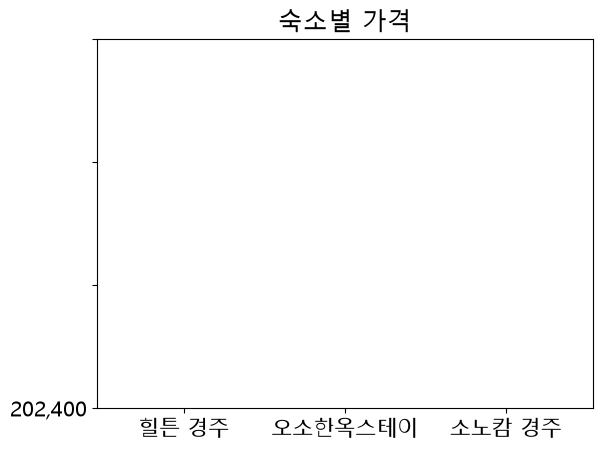

In [37]:
# 숙소명으로 그래프
title=df['숙소명'].head(3)
money=df['금액'].head(3)
x=title
y=money

plt.bar(x,y)
plt.title('숙소별 가격')
plt.yticks([0,100000,200000,300000])
